> ⚠️ **DE-LEAKED 정직본** — 누설 5개 제거 재실행. 정직 Tree R²=**0.42**, RF R²=**0.54**(누설본 0.86/0.93).
> 추출 규칙은 age_entropy·직장인구·biz 등 정상 피처로 분기(momentum/peer_avg_sales 누설 제거됨).

# 05. 해석 (v2 — 신규 변수 영향 검증)

답하는 질문:
1. 어느 (자치구, 업종)에서 빗나가는가? — 잔차 매트릭스
2. 단일 트리 vs RandomForest 중요도 차이
3. 충격기 vs 회복기 변수 중요도
4. **신규 변수(임대료·공실률·인구밀도)** 기여도 — permutation_importance
5. max_depth=3 단순 트리로 IF-THEN 정책 룰

In [1]:
from pathlib import Path
import numpy as np, pandas as pd
from sklearn.tree import DecisionTreeRegressor, plot_tree, _tree
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
import matplotlib, matplotlib.pyplot as plt, platform
matplotlib.rcParams['font.family'] = 'AppleGothic' if platform.system()=='Darwin' else 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False

PROCESSED_DIR = Path('/Users/ijunsu/Documents/Documents/capston/data_analysis/trade_area_project/data/processed')
df = pd.read_csv(PROCESSED_DIR / 'features.csv')

# 데이터 + 분할 준비 (04와 동일 규칙으로 self-contained)
id_cols = ['gu','biz','q','q_int']
target = 'log_sales'
feature_cols = [c for c in df.columns if c not in id_cols + ['THSMON_SELNG_AMT','log_sales','sales_class','sales_per_store','log_sales_per_store','store_class']]
feature_cols = [c for c in feature_cols if c not in ['avg_ticket','peer_avg_sales','momentum','margin_proxy','rent_to_sales']]  # de-leak(feature_cols)
df[feature_cols] = df[feature_cols].apply(pd.to_numeric, errors='coerce')
df[feature_cols] = df[feature_cols].fillna(df[feature_cols].mean(numeric_only=True))

train_mask = df['q_int'] < 20241
hold_mask  = df['q_int'] >= 20241
X_train, y_train = df.loc[train_mask, feature_cols].values, df.loc[train_mask, target]
X_hold,  y_hold  = df.loc[hold_mask, feature_cols].values, df.loc[hold_mask, target]

# 트리와 RF 모두 학습 — 두 모델 중요도 비교 + 잔차 분석에 사용
tree = DecisionTreeRegressor(max_depth=10, min_samples_split=5, random_state=42).fit(X_train, y_train)
rf   = RandomForestRegressor(n_estimators=200, max_depth=12, random_state=42, n_jobs=-1).fit(X_train, y_train)
print('학습 완료. 트리 R²(홀드):', round(tree.score(X_hold, y_hold),3),
      '| RF R²(홀드):', round(rf.score(X_hold, y_hold),3))

학습 완료. 트리 R²(홀드): 0.423 | RF R²(홀드): 0.538


## 1. 자치구 × 업종 잔차 매트릭스

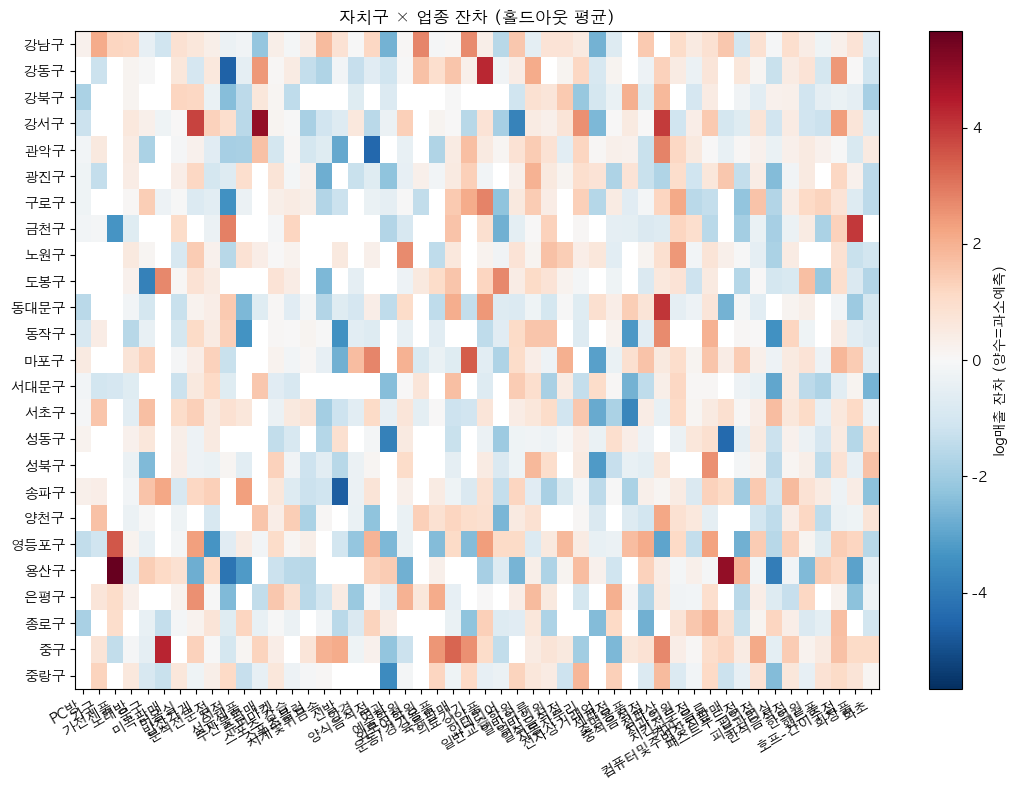

In [2]:
# 홀드아웃 행에 대해 잔차 = 실제 - 예측
hold_df = df.loc[hold_mask, ['gu','biz']].copy()
hold_df['actual']   = y_hold.values
hold_df['pred']     = rf.predict(X_hold)
hold_df['residual'] = hold_df['actual'] - hold_df['pred']
# 양수: 모델이 과소예측(실제가 더 큼), 음수: 과대예측

# 자치구·업종으로 피벗 → 어디서 잘 안 맞는지 한눈에
resid_mat = hold_df.pivot_table(index='gu', columns='biz', values='residual', aggfunc='mean')
fig, ax = plt.subplots(figsize=(11, 8))
vmax = np.nanmax(np.abs(resid_mat.values))               # 0 기준 좌우 대칭 컬러바
im = ax.imshow(resid_mat.values, cmap='RdBu_r', vmin=-vmax, vmax=vmax, aspect='auto')
ax.set_xticks(range(resid_mat.shape[1])); ax.set_xticklabels(resid_mat.columns, rotation=30, ha='right')
ax.set_yticks(range(resid_mat.shape[0])); ax.set_yticklabels(resid_mat.index)
plt.colorbar(im, label='log매출 잔차 (양수=과소예측)')
ax.set_title('자치구 × 업종 잔차 (홀드아웃 평균)'); plt.tight_layout(); plt.show()

## 2. 자치구별 잔차 박스플롯 — 어디가 변동 큰가

/tmp/claude-501/ipykernel_11932/2091654117.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=gu_order, showfliers=False)


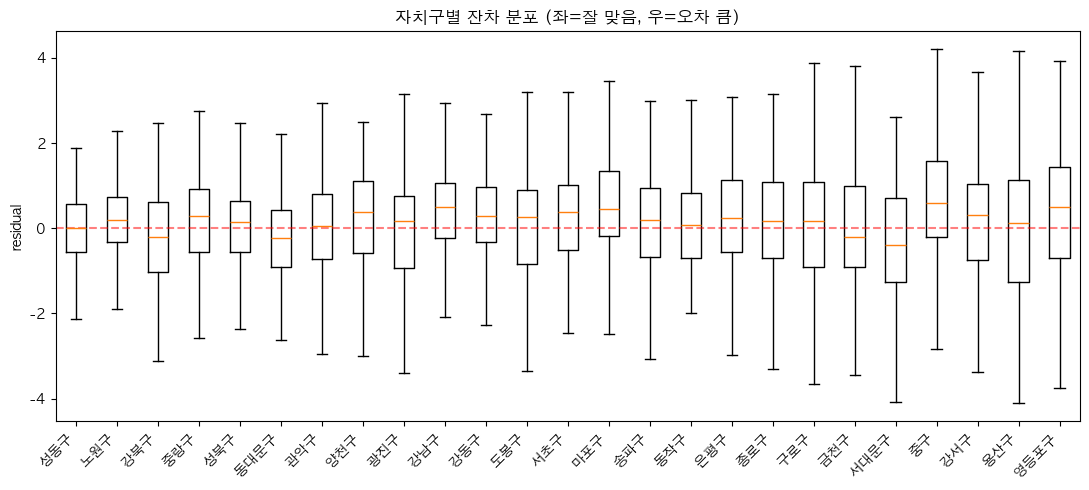

In [3]:
# 자치구별 절대 잔차 평균 기준 정렬 → 작은 것이 왼쪽(잘 맞음)
gu_order = hold_df.groupby('gu')['residual'].apply(lambda s: s.abs().mean()).sort_values().index.tolist()
data = [hold_df.loc[hold_df['gu']==g, 'residual'].values for g in gu_order]
fig, ax = plt.subplots(figsize=(11, 5))
ax.boxplot(data, labels=gu_order, showfliers=False)
ax.axhline(0, color='red', linestyle='--', alpha=0.5)
ax.set_title('자치구별 잔차 분포 (좌=잘 맞음, 우=오차 큼)')
ax.set_ylabel('residual'); plt.xticks(rotation=45, ha='right'); plt.tight_layout(); plt.show()

## 3. 단일 트리 vs RF 변수 중요도

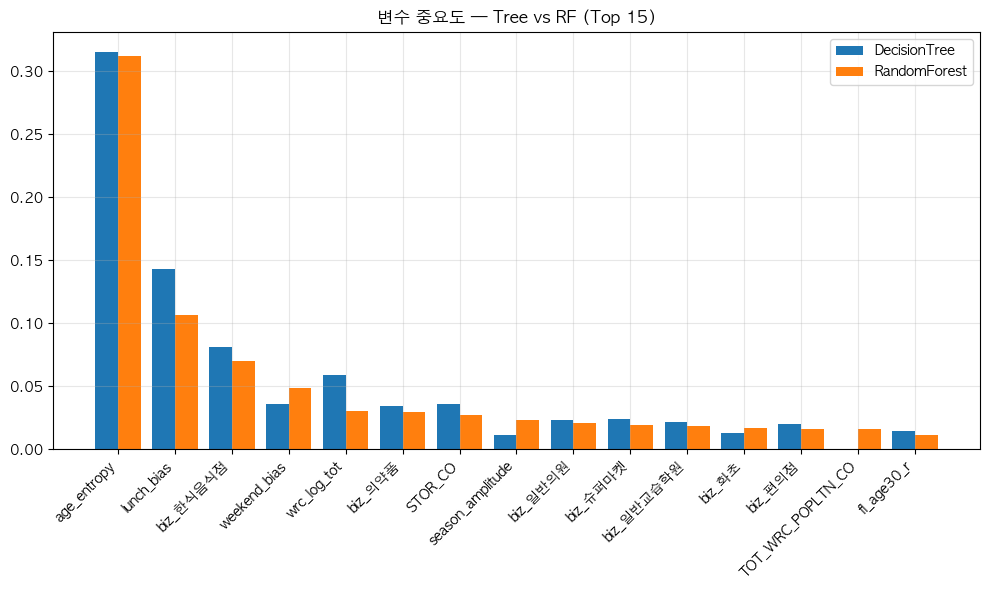

In [4]:
# feature_importances_: 트리가 분할 기준으로 변수를 얼마나 자주 쓰는지의 정규화 값
imp_tree = pd.Series(tree.feature_importances_, index=feature_cols)
imp_rf   = pd.Series(rf.feature_importances_, index=feature_cols)
# 두 모델을 한 표에 모아 Top 15만
comp = pd.DataFrame({'Tree': imp_tree, 'RF': imp_rf}).sort_values('RF', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(comp))
ax.bar(x - 0.2, comp['Tree'], 0.4, label='DecisionTree')
ax.bar(x + 0.2, comp['RF'],   0.4, label='RandomForest')
ax.set_xticks(x); ax.set_xticklabels(comp.index, rotation=45, ha='right')
ax.set_title('변수 중요도 — Tree vs RF (Top 15)')
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

## 4. 충격기 vs 회복기 — 중요도 비교

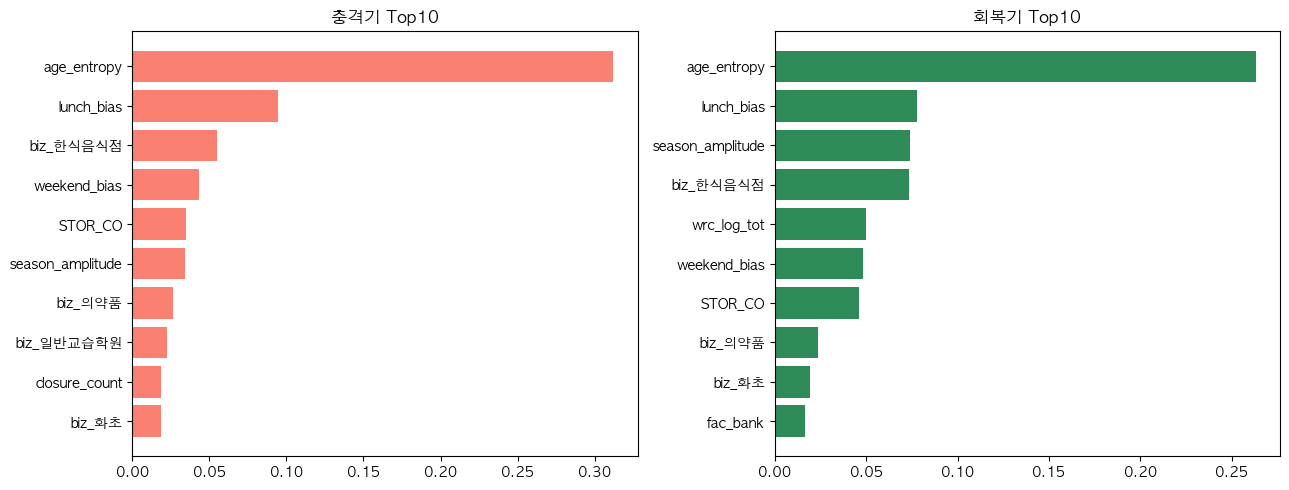

In [5]:
# 같은 모델을 두 시기로 따로 학습 → 시기별 중요도 차이 관찰
shock_mask = (df['q_int'] >= 20201) & (df['q_int'] <= 20214)        # 20Q1~21Q4
recov_mask =  df['q_int'] >= 20221                                    # 22Q1~

def fit_rf(mask):
    X = df.loc[mask, feature_cols].values
    y = df.loc[mask, target].values
    rf_ = RandomForestRegressor(n_estimators=150, max_depth=12, random_state=42, n_jobs=-1).fit(X, y)
    return pd.Series(rf_.feature_importances_, index=feature_cols)

imp_shock = fit_rf(shock_mask).sort_values(ascending=False).head(10)
imp_recov = fit_rf(recov_mask).sort_values(ascending=False).head(10)

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
ax[0].barh(imp_shock.index[::-1], imp_shock.values[::-1], color='salmon')
ax[0].set_title('충격기 Top10')
ax[1].barh(imp_recov.index[::-1], imp_recov.values[::-1], color='seagreen')
ax[1].set_title('회복기 Top10')
plt.tight_layout(); plt.show()

## 5. permutation_importance — 신규 변수 기여도

Exception ignored in: <function ResourceTracker.__del__ at 0x1050d72e0>
Traceback (most recent call last):
  File "/Users/ijunsu/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/Users/ijunsu/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/Users/ijunsu/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
/Users/ijunsu/anaconda3/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Exception ignored in: <function ResourceTracker.__del__ at 0x104b8b2e0>
Traceback (most recent call last):
  File "/Users/ijunsu/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/Users/ijunsu/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/Users/ijunsu/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes


Exception ignored in: <function ResourceTracker.__del__ at 0x1102e32e0>
Traceback (most recent call last):
  File "/Users/ijunsu/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/Users/ijunsu/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/Users/ijunsu/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes


Exception ignored in: <function ResourceTracker.__del__ at 0x107f6b2e0>
Traceback (most recent call last):
  File "/Users/ijunsu/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/Users/ijunsu/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/Users/ijunsu/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes


Exception ignored in: <function ResourceTracker.__del__ at 0x1080672e0>
Traceback (most recent call last):
  File "/Users/ijunsu/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/Users/ijunsu/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/Users/ijunsu/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes


Exception ignored in: <function ResourceTracker.__del__ at 0x1114932e0>
Traceback (most recent call last):
  File "/Users/ijunsu/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/Users/ijunsu/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/Users/ijunsu/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes


Exception ignored in: <function ResourceTracker.__del__ at 0x105a6b2e0>
Traceback (most recent call last):
  File "/Users/ijunsu/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/Users/ijunsu/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/Users/ijunsu/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes


Exception ignored in: <function ResourceTracker.__del__ at 0x1072672e0>
Traceback (most recent call last):
  File "/Users/ijunsu/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/Users/ijunsu/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/Users/ijunsu/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes


Exception ignored in: <function ResourceTracker.__del__ at 0x10627b2e0>
Traceback (most recent call last):
  File "/Users/ijunsu/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/Users/ijunsu/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/Users/ijunsu/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes


Exception ignored in: <function ResourceTracker.__del__ at 0x10431f2e0>
Traceback (most recent call last):
  File "/Users/ijunsu/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/Users/ijunsu/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/Users/ijunsu/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes


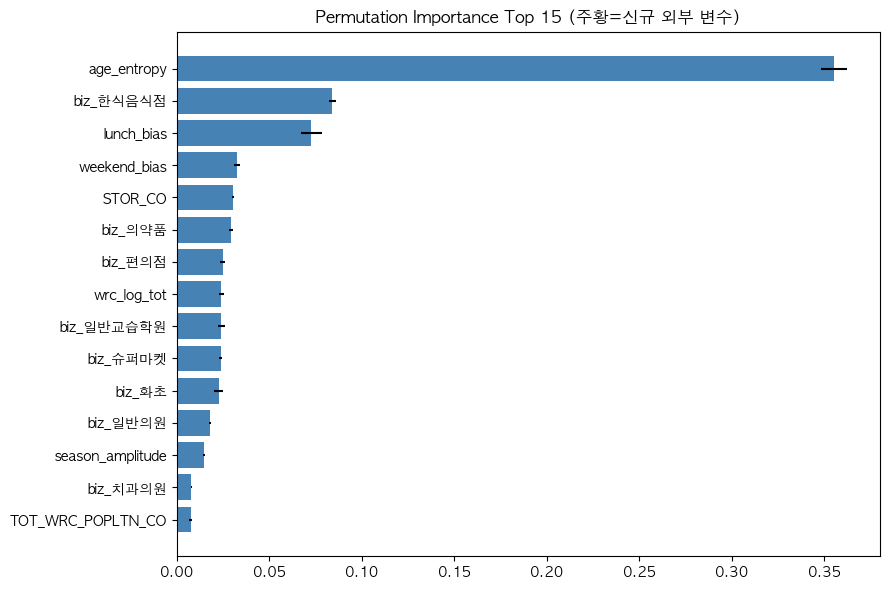

신규 변수가 Top 15에 진입한 개수: 0


In [6]:
# permutation_importance: 변수 값을 무작위 셔플 → 성능 하락폭이 그 변수의 진짜 기여도
# feature_importances_와 달리 학습 셋 편향 없음 (홀드아웃에서 평가)
perm = permutation_importance(rf, X_hold, y_hold, n_repeats=5, random_state=42, n_jobs=-1)
perm_df = pd.DataFrame({'feature': feature_cols,
                         'perm_imp': perm.importances_mean,
                         'std': perm.importances_std}).sort_values('perm_imp', ascending=False).head(15)

# 신규 외부 변수는 주황색, 기존 변수는 파랑 — 시각적으로 신규 기여도 강조
new_vars = {'rent_index_q','rent_growth_yoy','vacancy_rate','margin_proxy',
            'gu_pop_density','closure_count','single_household','transaction_count_q',
            'avg_transaction_price','gu_foreign_ratio','rent_to_sales','vacancy_change_q',
            'pop_density_log','single_ratio','closure_per_store','margin_zscore'}
colors = ['orange' if f in new_vars else 'steelblue' for f in perm_df['feature']]

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(perm_df['feature'][::-1], perm_df['perm_imp'][::-1],
        xerr=perm_df['std'][::-1], color=colors[::-1])
ax.set_title('Permutation Importance Top 15 (주황=신규 외부 변수)')
plt.tight_layout(); plt.show()
print(f'신규 변수가 Top 15에 진입한 개수: {sum(c == "orange" for c in colors)}')

## 6. 단순 트리(max_depth=3) → 정책 룰 추출

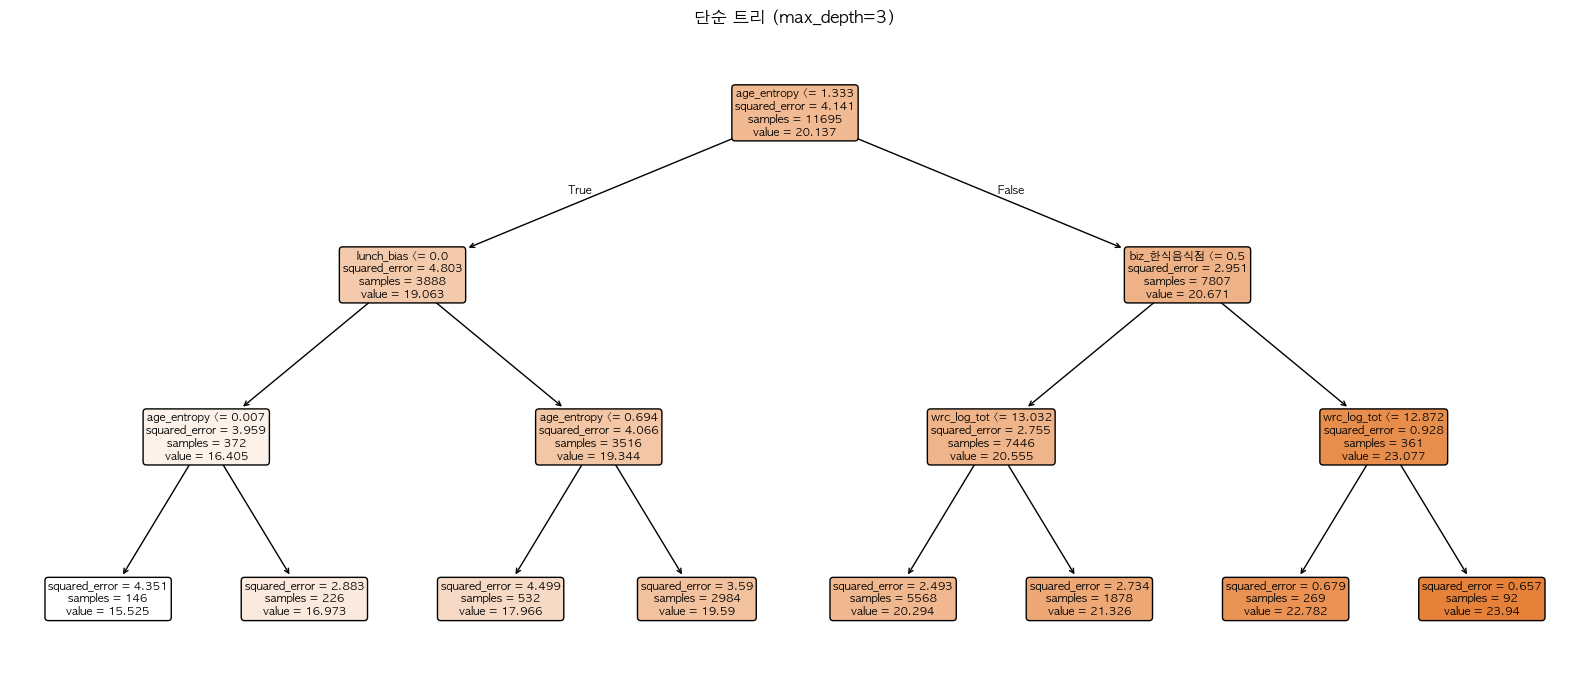

In [7]:
# 깊이를 3으로 제한 → 사람이 읽을 수 있는 IF-THEN 규칙으로 변환 가능한 단순한 트리
tree_simple = DecisionTreeRegressor(max_depth=3, min_samples_split=20, random_state=42).fit(X_train, y_train)
fig, ax = plt.subplots(figsize=(16, 7))
plot_tree(tree_simple, feature_names=feature_cols, filled=True, rounded=True, fontsize=8, ax=ax)
plt.title('단순 트리 (max_depth=3)'); plt.tight_layout(); plt.show()

In [8]:
def tree_to_rules(tree_model, feat_names):
    """sklearn 트리 객체를 IF-THEN 룰 리스트로 변환 — 강의 외 1건 (정책 룰 추출용)."""
    t = tree_model.tree_
    rules = []
    def recurse(node, conds):
        # 내부 노드면 좌(조건 만족)·우(불만족)로 재귀
        if t.feature[node] != _tree.TREE_UNDEFINED:
            name = feat_names[t.feature[node]]
            th = t.threshold[node]
            recurse(t.children_left[node],  conds + [f'{name} <= {th:.3f}'])
            recurse(t.children_right[node], conds + [f'{name} > {th:.3f}'])
        else:
            # 리프 노드 → 룰 1건 (예측값 + 표본수)
            rules.append({'conds': ' AND '.join(conds),
                          'pred_log_sales': float(t.value[node][0][0]),
                          'samples': int(t.n_node_samples[node])})
    recurse(0, [])
    return pd.DataFrame(rules).sort_values('pred_log_sales', ascending=False).reset_index(drop=True)

rules = tree_to_rules(tree_simple, feature_cols)
print(f'추출된 룰 수: {len(rules)}')
rules

추출된 룰 수: 8


,conds,pred_log_sales,samples
0,age_entropy > 1.333 AND biz_한식음식점 > 0.500 AND ...,23.939915,92
1,age_entropy > 1.333 AND biz_한식음식점 > 0.500 AND ...,22.781879,269
2,age_entropy > 1.333 AND biz_한식음식점 <= 0.500 AND...,21.326229,1878
3,age_entropy > 1.333 AND biz_한식음식점 <= 0.500 AND...,20.294269,5568
4,age_entropy <= 1.333 AND lunch_bias > 0.000 AN...,19.590087,2984
5,age_entropy <= 1.333 AND lunch_bias > 0.000 AN...,17.965671,532
6,age_entropy <= 1.333 AND lunch_bias <= 0.000 A...,16.973421,226
7,age_entropy <= 1.333 AND lunch_bias <= 0.000 A...,15.524898,146


## 7. 최상/중위/최하 룰 — 보고서 인용용

In [9]:
# 정책 제언에 직접 인용할 수 있는 3가지 대표 룰
top = rules.iloc[0]                       # 매출 최상위
mid = rules.iloc[len(rules)//2]           # 중간
low = rules.iloc[-1]                      # 최하위 (피해야 하는 조건)

print('— 최상위 룰 —')
print(top['conds'], f'\n→ log_sales={top["pred_log_sales"]:.2f} (실매출 ≈ {np.exp(top["pred_log_sales"])/1e8:.1f}억), 표본={top["samples"]}')
print('\n— 중위 룰 —')
print(mid['conds'], f'\n→ log_sales={mid["pred_log_sales"]:.2f}, 표본={mid["samples"]}')
print('\n— 최하위 룰 —')
print(low['conds'], f'\n→ log_sales={low["pred_log_sales"]:.2f}, 표본={low["samples"]}')

— 최상위 룰 —
age_entropy > 1.333 AND biz_한식음식점 > 0.500 AND wrc_log_tot > 12.872 
→ log_sales=23.94 (실매출 ≈ 249.4억), 표본=92

— 중위 룰 —
age_entropy <= 1.333 AND lunch_bias > 0.000 AND age_entropy > 0.694 
→ log_sales=19.59, 표본=2984

— 최하위 룰 —
age_entropy <= 1.333 AND lunch_bias <= 0.000 AND age_entropy <= 0.007 
→ log_sales=15.52, 표본=146
